Project objective: To show that Muslim girls deserve to have their religion respected. What is the point of placing someone in a school by merit if she won't have her religion respected, and she'll be forced to take off her hijab? My religion won't bar me or anyone else from learning. And this is a double-edged sword. Christians shouldn't be forced to put on the hijab either. 

1. Loading the dataset                                                                                    
   320+ rows of schools that had to be skipped, as they were not in the correct format, from the initial 9569

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(
    r"C:\Users\DELL\Documents\Yasmin's projects\tabula-senior-schools-in-kenya.csv",
    engine='python',
    on_bad_lines='skip'
)

df.head()


,S/No.,REGION,COUNTY,SUB COUNTY,UIC,KNEC,SCHOOL NAME,CLUSTER,TYPE,(Regular/ SNE/,TYPE,ACCOMODATION TYPE,GENDER
0,1,RIFT VALLEY,BARINGO,BARINGO CENTRAL,7J98,33517209,A I C PHILEMON CHELAGAT GIRLS,C3,PUBLIC,REGULAR,NONE,BOARDING,GIRLS
1,2,RIFT VALLEY,BARINGO,BARINGO CENTRAL,GMUY,33517103,AIC KAPKELELWA SECONDARY SCHOOL,C3,PUBLIC,REGULAR,NONE,BOARDING,MIXED
2,3,RIFT VALLEY,BARINGO,BARINGO CENTRAL,5XVV,33517112,BEKIBON SECONDARY SCHOOL,C4,PUBLIC,REGULAR,NONE,DAY,MIXED
3,4,RIFT VALLEY,BARINGO,BARINGO CENTRAL,5PK2,33517110,CHEPKERO MIXED DAY SECONDARY SCHOOL,C4,PUBLIC,REGULAR,NONE,DAY,MIXED
4,5,RIFT VALLEY,BARINGO,BARINGO CENTRAL,WDP3,33517223,CHESONGO MIXED DAY SECONDARY SCHOOL,C4,PUBLIC,REGULAR,NONE,DAY,MIXED


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9247 entries, 0 to 9246
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   S/No.              9247 non-null   int64 
 1   REGION             9247 non-null   object
 2   COUNTY             9247 non-null   object
 3   SUB COUNTY         9247 non-null   object
 4   UIC                9247 non-null   object
 5   KNEC               9247 non-null   int64 
 6   SCHOOL NAME        9247 non-null   object
 7   CLUSTER            9247 non-null   object
 8   TYPE               9247 non-null   object
 9   (Regular/  SNE/    9247 non-null   object
 10   TYPE              9247 non-null   object
 11  ACCOMODATION TYPE  9247 non-null   object
 12  GENDER             9246 non-null   object
dtypes: int64(2), object(11)
memory usage: 939.3+ KB


2. Data cleaning

                                          I. Fixing columns 8 and 10 

In [9]:
df.columns

Index(['S/No.', 'REGION', 'COUNTY', 'SUB COUNTY', 'UIC', 'KNEC', 'SCHOOL NAME',
       'CLUSTER', 'TYPE', '(Regular/  SNE/', ' TYPE', 'ACCOMODATION TYPE',
       'GENDER'],
      dtype='object')

In [10]:
df.columns = ["SERIAL NO.", "REGION", "COUNTY", "SUB COUNTY", "UIC", "KNEC", "SCHOOL NAME", "CLUSTER", "TYPE", "REGULAR OR SNE", "DISABILITY TYPE", "ACCOMODATION TYPE", "GENDER"]

In [11]:
df.head()

,SERIAL NO.,REGION,COUNTY,SUB COUNTY,UIC,KNEC,SCHOOL NAME,CLUSTER,TYPE,REGULAR OR SNE,DISABILITY TYPE,ACCOMODATION TYPE,GENDER
0,1,RIFT VALLEY,BARINGO,BARINGO CENTRAL,7J98,33517209,A I C PHILEMON CHELAGAT GIRLS,C3,PUBLIC,REGULAR,NONE,BOARDING,GIRLS
1,2,RIFT VALLEY,BARINGO,BARINGO CENTRAL,GMUY,33517103,AIC KAPKELELWA SECONDARY SCHOOL,C3,PUBLIC,REGULAR,NONE,BOARDING,MIXED
2,3,RIFT VALLEY,BARINGO,BARINGO CENTRAL,5XVV,33517112,BEKIBON SECONDARY SCHOOL,C4,PUBLIC,REGULAR,NONE,DAY,MIXED
3,4,RIFT VALLEY,BARINGO,BARINGO CENTRAL,5PK2,33517110,CHEPKERO MIXED DAY SECONDARY SCHOOL,C4,PUBLIC,REGULAR,NONE,DAY,MIXED
4,5,RIFT VALLEY,BARINGO,BARINGO CENTRAL,WDP3,33517223,CHESONGO MIXED DAY SECONDARY SCHOOL,C4,PUBLIC,REGULAR,NONE,DAY,MIXED


                                             II. Dropping irrelevant columns

In [14]:
df = df.drop(columns=['UIC', 'KNEC', 'REGULAR OR SNE'])

                                           III. Filling missing value Gender

In [16]:
missing_gender = df[df['GENDER'].isna()]

In [17]:
print(missing_gender)

      SERIAL NO.       REGION      COUNTY  SUB COUNTY  \
9246        9569  RIFT VALLEY  WEST POKOT  WEST POKOT   

                               SCHOOL NAME CLUSTER    TYPE DISABILITY TYPE  \
9246  TURKWEL GORGE MIXED SECONDARY SCHOOL      C4  PUBLIC             DAY   

     ACCOMODATION TYPE GENDER  
9246             Mixed    NaN  


In [18]:
 df['GENDER'].fillna('Mixed')

0       GIRLS
1       MIXED
2       MIXED
3       MIXED
4       MIXED
        ...  
9242    Mixed
9243    Mixed
9244    Mixed
9245    Mixed
9246    Mixed
Name: GENDER, Length: 9247, dtype: object

In [19]:
print(missing_gender)

      SERIAL NO.       REGION      COUNTY  SUB COUNTY  \
9246        9569  RIFT VALLEY  WEST POKOT  WEST POKOT   

                               SCHOOL NAME CLUSTER    TYPE DISABILITY TYPE  \
9246  TURKWEL GORGE MIXED SECONDARY SCHOOL      C4  PUBLIC             DAY   

     ACCOMODATION TYPE GENDER  
9246             Mixed    NaN  


                                  IV. Ensuring all the data is in title case

In [21]:
cols_to_clean = ['REGION', 'COUNTY', 'SUB COUNTY', 'SCHOOL NAME', 'TYPE', 'DISABILITY TYPE', 'ACCOMODATION TYPE', 'GENDER']
df[cols_to_clean] = df[cols_to_clean].apply(lambda x: x.str.strip().str.title())

In [22]:
df.head()

,SERIAL NO.,REGION,COUNTY,SUB COUNTY,SCHOOL NAME,CLUSTER,TYPE,DISABILITY TYPE,ACCOMODATION TYPE,GENDER
0,1,Rift Valley,Baringo,Baringo Central,A I C Philemon Chelagat Girls,C3,Public,None,Boarding,Girls
1,2,Rift Valley,Baringo,Baringo Central,Aic Kapkelelwa Secondary School,C3,Public,None,Boarding,Mixed
2,3,Rift Valley,Baringo,Baringo Central,Bekibon Secondary School,C4,Public,None,Day,Mixed
3,4,Rift Valley,Baringo,Baringo Central,Chepkero Mixed Day Secondary School,C4,Public,None,Day,Mixed
4,5,Rift Valley,Baringo,Baringo Central,Chesongo Mixed Day Secondary School,C4,Public,None,Day,Mixed


3. Data exploration

                          I. ARE THE SCHOOLS PUBLIC OR PRIVATE?

          The schools are meant to be public schools where students can be placed in fairly

In [26]:
school_type = df[df["TYPE"].str.contains("Public", case = False, na = False)]

In [27]:
school_type

,SERIAL NO.,REGION,COUNTY,SUB COUNTY,SCHOOL NAME,CLUSTER,TYPE,DISABILITY TYPE,ACCOMODATION TYPE,GENDER
0,1,Rift Valley,Baringo,Baringo Central,A I C Philemon Chelagat Girls,C3,Public,None,Boarding,Girls
1,2,Rift Valley,Baringo,Baringo Central,Aic Kapkelelwa Secondary School,C3,Public,None,Boarding,Mixed
2,3,Rift Valley,Baringo,Baringo Central,Bekibon Secondary School,C4,Public,None,Day,Mixed
3,4,Rift Valley,Baringo,Baringo Central,Chepkero Mixed Day Secondary School,C4,Public,None,Day,Mixed
4,5,Rift Valley,Baringo,Baringo Central,Chesongo Mixed Day Secondary School,C4,Public,None,Day,Mixed
...,...,...,...,...,...,...,...,...,...,...
9242,9565,Rift Valley,West Pokot,West Pokot,Talau Mixed Day Secondary School,C4,Public,None,Day,Mixed
9243,9566,Rift Valley,West Pokot,West Pokot,Tilak Mixed Secondary School,C4,Public,None,Day,Mixed
9244,9567,Rift Valley,West Pokot,West Pokot,Tomena Mixed Day Secondary School,C4,Public,None,Day,Mixed
9245,9568,Rift Valley,West Pokot,West Pokot,Totum Mixed Day Secondary School,C4,Public,None,Day,Mixed


In [28]:
school_type.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9247 entries, 0 to 9246
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SERIAL NO.         9247 non-null   int64 
 1   REGION             9247 non-null   object
 2   COUNTY             9247 non-null   object
 3   SUB COUNTY         9247 non-null   object
 4   SCHOOL NAME        9247 non-null   object
 5   CLUSTER            9247 non-null   object
 6   TYPE               9247 non-null   object
 7   DISABILITY TYPE    9247 non-null   object
 8   ACCOMODATION TYPE  9247 non-null   object
 9   GENDER             9246 non-null   object
dtypes: int64(1), object(9)
memory usage: 722.6+ KB


                             II. How many schools are muslim schools?

     We will check for Muslim schools that scream that it is obviously a Muslim school. We will then add a column for such schools for visualizations

In [31]:
muslim_schools = df[df["SCHOOL NAME"].str.contains(r"Muslim|Sheikh|Sheiykh|Islamic|Islam", case = False, na = False)]

In [32]:
muslim_schools

,SERIAL NO.,REGION,COUNTY,SUB COUNTY,SCHOOL NAME,CLUSTER,TYPE,DISABILITY TYPE,ACCOMODATION TYPE,GENDER
613,707,Western,Bungoma,Bungoma West,Malakisi Muslim High School,C4,Public,None,Day,Mixed
1488,1605,Nyanza,Homa Bay,Rachuonyo Nort,Kendu Muslim Secondary School,C4,Public,None,Day,Mixed
1666,1788,Eastern,Isiolo,Merti,Merti Muslim Girls' Secondary School,C3,Public,None,Boarding,Girls
1814,1940,Western,Kakamega,Kakamega Centr,Kakamega Muslim Secondary School,C4,Public,None,Day,Mixed
2036,2168,Western,Kakamega,Lugari,Macho Muslim Secondary School,C4,Public,None,Day,Mixed
2075,2208,Western,Kakamega,Matungu,Busombi Muslim Mixed,C4,Public,None,Day,Mixed
2077,2210,Western,Kakamega,Matungu,Emanani Muslim Secondary School,C4,Public,None,Day,Mixed
2078,2211,Western,Kakamega,Matungu,Eshibanze Muslim,C4,Public,None,Day,Mixed
2081,2214,Western,Kakamega,Matungu,Makunda Muslim Secondary School,C3,Public,None,Boarding,Mixed
2084,2218,Western,Kakamega,Matungu,Namulungu Muslim Secondary School,C4,Public,None,Day,Mixed


In [33]:
muslim_schools.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 613 to 9007
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SERIAL NO.         24 non-null     int64 
 1   REGION             24 non-null     object
 2   COUNTY             24 non-null     object
 3   SUB COUNTY         24 non-null     object
 4   SCHOOL NAME        24 non-null     object
 5   CLUSTER            24 non-null     object
 6   TYPE               24 non-null     object
 7   DISABILITY TYPE    24 non-null     object
 8   ACCOMODATION TYPE  24 non-null     object
 9   GENDER             24 non-null     object
dtypes: int64(1), object(9)
memory usage: 2.1+ KB


Please note that many schools you would expect to see are missing. This is because 323 schools were skipped, so we could read the rest of the dataset with no errors. This does not change much, because the ratio of Muslim schools to those that are not based on the Muslim faith is still low - whether the schools are included or not

                                     III. Muslim girl schools

In [36]:
muslim_girl_schools = df[df["SCHOOL NAME"].str.contains(r"Muslim Girls", case = False, na = False)]

In [37]:
muslim_girl_schools

,SERIAL NO.,REGION,COUNTY,SUB COUNTY,SCHOOL NAME,CLUSTER,TYPE,DISABILITY TYPE,ACCOMODATION TYPE,GENDER
1666,1788,Eastern,Isiolo,Merti,Merti Muslim Girls' Secondary School,C3,Public,None,Boarding,Girls
2145,2280,Western,Kakamega,Mumias West,Mumias Muslim Girls Secondary School,C3,Public,None,Boarding,Girls


                            IV. Creating a column comparing muslim schools and Christian or secular school

In [39]:
not_muslim_schools = df[~df["SCHOOL NAME"].str.contains(r"Muslim|Sheikh|Sheiykh|Islamic|Islam", case=False, na=False)]

In [40]:
not_muslim_schools.info

<bound method DataFrame.info of       SERIAL NO.       REGION      COUNTY       SUB COUNTY  \
0              1  Rift Valley     Baringo  Baringo Central   
1              2  Rift Valley     Baringo  Baringo Central   
2              3  Rift Valley     Baringo  Baringo Central   
3              4  Rift Valley     Baringo  Baringo Central   
4              5  Rift Valley     Baringo  Baringo Central   
...          ...          ...         ...              ...   
9242        9565  Rift Valley  West Pokot       West Pokot   
9243        9566  Rift Valley  West Pokot       West Pokot   
9244        9567  Rift Valley  West Pokot       West Pokot   
9245        9568  Rift Valley  West Pokot       West Pokot   
9246        9569  Rift Valley  West Pokot       West Pokot   

                               SCHOOL NAME CLUSTER    TYPE DISABILITY TYPE  \
0            A I C Philemon Chelagat Girls      C3  Public            None   
1          Aic Kapkelelwa Secondary School      C3  Public         

In [46]:
df['RELIGION'] = df['SCHOOL NAME'].str.contains(r"Muslim|Sheikh|Sheiykh|Islamic|Islam", case=False, na=False)
df['RELIGION'] = df['RELIGION'].map({True: 'Muslim', False: 'Not Muslim'})

In [48]:
df.head()

,SERIAL NO.,REGION,COUNTY,SUB COUNTY,SCHOOL NAME,CLUSTER,TYPE,DISABILITY TYPE,ACCOMODATION TYPE,GENDER,RELIGION
0,1,Rift Valley,Baringo,Baringo Central,A I C Philemon Chelagat Girls,C3,Public,None,Boarding,Girls,Not Muslim
1,2,Rift Valley,Baringo,Baringo Central,Aic Kapkelelwa Secondary School,C3,Public,None,Boarding,Mixed,Not Muslim
2,3,Rift Valley,Baringo,Baringo Central,Bekibon Secondary School,C4,Public,None,Day,Mixed,Not Muslim
3,4,Rift Valley,Baringo,Baringo Central,Chepkero Mixed Day Secondary School,C4,Public,None,Day,Mixed,Not Muslim
4,5,Rift Valley,Baringo,Baringo Central,Chesongo Mixed Day Secondary School,C4,Public,None,Day,Mixed,Not Muslim


In [50]:
df['RELIGION'].value_counts()

RELIGION
Not Muslim    9223
Muslim          24
Name: count, dtype: int64

4. Data visualization

Out of 9153 Public schools, only 24 are Muslim... Out of those, there is a mixture of Girls, Boys, and Mixed High Schools. Not all Muslim girls can be placed in these schools.                         
Muslim girls deserve to have their religion respected. We can't be a hypocritical nation. Respecting Islam in the constitution, but in reality, the hijab is treated like a garment that prevents learning.                                                                                                  Covering one's head for religious purposes does not prevent comprehension or "absorption" of content. It also doesn't distract others, unless they themselves are not focused on why they're in school, hence, a them problem

Respect and cohesion starts from a young age. So does discrimination. It is both due to nature and and nurture. Preventing religious covering, especially for religions recognized by the nation, IS discriminatory and demeaning. 

                           I. Distribution

           i. Bar chart
        

<Axes: xlabel='RELIGION'>

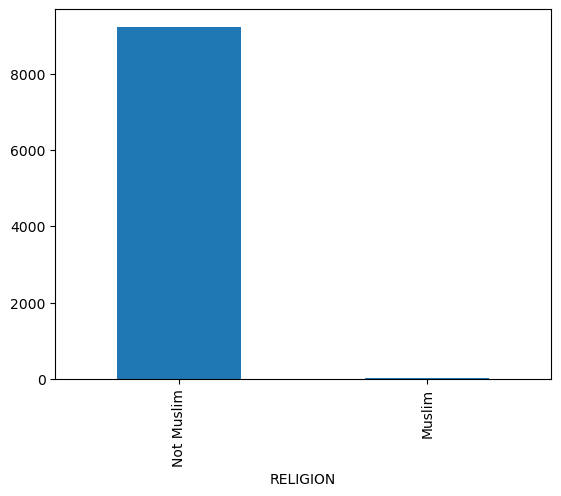

In [57]:
df['RELIGION'].value_counts().plot(kind = 'bar')

                                    ii. Pie chart

<Axes: ylabel='count'>

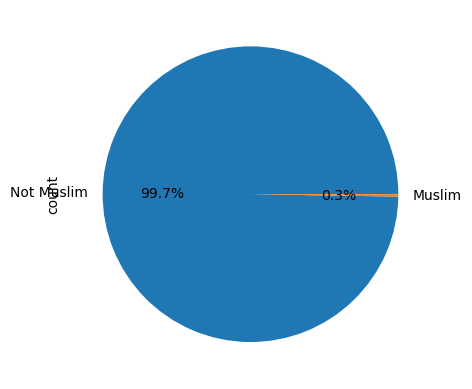

In [63]:
df['RELIGION'].value_counts().plot(kind='pie', autopct='%1.1f%%')

                                    II. Regional distributions

                                    i. Grouped bar chart

<Axes: xlabel='REGION'>

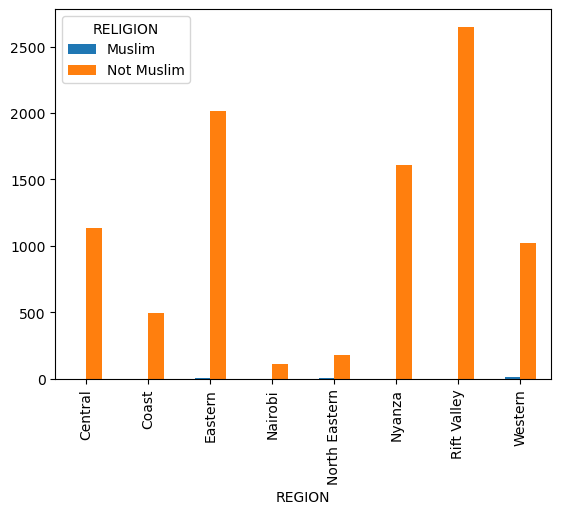

In [69]:
pd.crosstab(df['REGION'], df['RELIGION']).plot(kind='bar')

Most Muslim schools are found in Western Kenya - building on the colonial aspect of religion, the Arabization of Islam, and how it affects the African understanding of Islam in comparison to other religions brought to us, and furthermore solidifying the topic of Islamophobia in Kenya.                                                                                        


A decent amount are also found in North Eastern and Eastern Kenya, based on this grouped bar chart.

The stacked bar chart below shows the same thing.

                             ii. Stacked bar chart

<Axes: xlabel='REGION'>

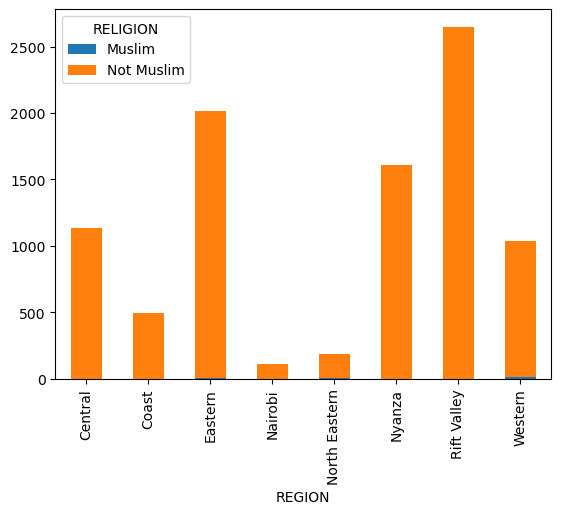

In [77]:
pd.crosstab(df['REGION'], df['RELIGION']).plot(kind='bar', stacked=True)

                                   III. Religion

                                 Grouped bar chart

<Axes: xlabel='GENDER'>

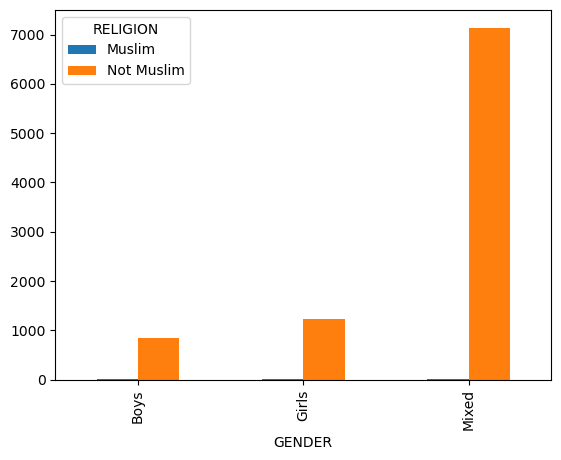

In [85]:
pd.crosstab(df['GENDER'], df['RELIGION']).plot(kind='bar')